In [1]:
import sys
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from pathlib import Path

_root = Path.cwd()
while not (_root / "src").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from src import config, data_utils, analysis

DATA_DIR = config.DATA_DIR
TRAIN_PATH = config.TRAIN_PATH
FIGURES_DIR = config.FIGURES_DIR


In [ ]:
zero_var_cols = pd.read_csv(DATA_DIR / "common_zero_var_cols.csv")["metric"].tolist()


In [ ]:
prices       = data_utils.load_metric_wide(TRAIN_PATH, pl.col("metric").str.starts_with("price"))
corr, Z      = analysis.compute_correlation_linkage(prices)


In [9]:
from scipy.cluster.hierarchy import fcluster

clusters_price = fcluster(Z, t=15, criterion="maxclust")

cluster_map_price = dict(zip(prices.columns, clusters_price))


cluster_df_price = pd.DataFrame({
    "feature": prices.columns,
    "cluster": clusters_price
})

In [10]:
zoom_cols = cluster_df_price[cluster_df_price["cluster"] == 14]["feature"].tolist()

In [11]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# # -----------------------------
# # Inset dendrogram
# # -----------------------------
zoom_corr = prices[zoom_cols].corr(method="pearson").abs()
zoom_dist = (1 - zoom_corr).clip(lower=0)

Z_zoom = linkage(squareform(zoom_dist, checks=False), method="ward")

In [12]:
ddata = dendrogram(
    Z,
    truncate_mode="lastp",
    p=10,
    no_plot=True
)

shown_nodes = ddata["leaves"]


In [13]:
zdata = dendrogram(
    Z_zoom,
    truncate_mode="lastp",
    p=10,
    no_plot=True
)

shown_nodes_zoom = zdata["leaves"]

In [14]:
n = len(prices.columns)

def get_cluster_members(node_id, Z, labels):
    """
    Given a dendrogram node ID, return original feature names inside it.
    """
    if node_id < n:
        return [labels[node_id]]
    
    row = int(node_id - n)
    left = int(Z[row, 0])
    right = int(Z[row, 1])
    
    return (
        get_cluster_members(left, Z, labels)
        + get_cluster_members(right, Z, labels)
    )

In [15]:
last10_clusters = []

for i, node in enumerate(shown_nodes, start=1):
    members = get_cluster_members(node, Z, list(prices.columns))
    
    last10_clusters.append({
        "display_cluster": i,
        "node_id": node,
        "n_features": len(members),
        "features": members
    })

last10_df = pd.DataFrame(last10_clusters)

In [16]:
from collections import Counter
import re

STOPWORDS = {
    "usd", "pct", "count", "price",
    "mean", "median", "sum", "close",
    "open", "high", "low"
}

def cluster_topic(cols):

    tokens = []

    for col in cols:
        parts = re.split(r"[_\W]+", col.lower())
        tokens.extend([
            p for p in parts
            if p and p not in STOPWORDS
        ])

    counts = Counter(tokens)

    top = [w for w, _ in counts.most_common(3)]

    return " / ".join(top)

In [17]:
cluster_names = {}

for row in last10_clusters:
    cluster_id = row["display_cluster"]
    cols = row["features"]
    cluster_names[cluster_id] = cluster_topic(cols)


In [18]:
import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

def clean_feature_name(col):
    # split snake_case / punctuation into words
    col = col.lower()
    col = re.sub(r"[_\W]+", " ", col)
    return col

cluster_docs = []

for row in last10_clusters:
    cluster_id = row["display_cluster"]
    features = row["features"]

    doc = " ".join(clean_feature_name(col) for col in features)

    cluster_docs.append({
        "cluster": cluster_id,
        "doc": doc,
        "n_features": len(features)
    })

cluster_docs_df = pd.DataFrame(cluster_docs)

In [19]:
vectorizer = TfidfVectorizer(
    stop_words=[
        "usd", "pct", "count", "total", "mean", "median",
        "sum", "value", "ratio", "index"
    ],
    ngram_range=(1, 2),   # allows single words and phrases
    min_df=1
)

X_tfidf = vectorizer.fit_transform(cluster_docs_df["doc"])

terms = vectorizer.get_feature_names_out()

In [20]:
def top_tfidf_terms(row_idx, top_n=5):
    scores = X_tfidf[row_idx].toarray().ravel()
    top_idx = scores.argsort()[::-1][:top_n]

    return [(terms[i], scores[i]) for i in top_idx if scores[i] > 0]

cluster_topics = []

for i, row in cluster_docs_df.iterrows():
    top_terms = top_tfidf_terms(i, top_n=5)

    cluster_topics.append({
        "cluster": row["cluster"],
        "n_features": row["n_features"],
        "top_terms": [term for term, score in top_terms],
        "suggested_label": " / ".join(term for term, score in top_terms[:3])
    })

topics_df = pd.DataFrame(cluster_topics)

In [21]:
cluster_label_map = dict(
    zip(topics_df["cluster"], topics_df["suggested_label"])
)

cluster_label_map

{1: 'price / 5sd / 5sd price',
 2: 'sats / sats price / price',
 3: 'price / ema / 5sd',
 4: 'price / 5sd / 5sd price',
 5: '0sd sats / sats / sats price',
 6: '1y / price / 5sd price',
 7: 'price / ema / sma',
 8: 'sma price / sma / price',
 9: 'zscore / zscore price / price',
 10: 'sats / sats price / price'}

In [22]:
cluster_label_map = {
    1: "Volatility",
    2: "Supply",
    3: "Momentum",
    4: "Price Dispersion",
    5: "Supply-Distribution",
    6: "LT Structure",
    7: "MA Signals",
    8: "Trend Smoothing",
    9: "Standardized Deviations",
    10: "Volume Activity"
}

In [23]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

# Get exact displayed nodes from the truncated dendrogram
ddata = dendrogram(
    Z,
    truncate_mode="lastp",
    p=10,
    no_plot=True
)

shown_nodes = ddata["leaves"]

# Map actual dendrogram node ids -> your semantic labels
node_label_map = {
    node: cluster_label_map[i]
    for i, node in enumerate(shown_nodes, start=1)
}

def label_func(node_id):
    return node_label_map.get(node_id, str(node_id))

# -----------------------------
# Inset dendrogram
# -----------------------------
zoom_corr = prices[zoom_cols].corr(method="pearson").abs()
zoom_dist = 1 - zoom_corr

Z_zoom = linkage(squareform(zoom_dist, checks=False), method="ward")


In [24]:
selected_cluster_id = 10  # whichever of the last 10 clusters you are zooming into
zoom_cols = last10_clusters[selected_cluster_id - 1]["features"]

zoom_label = cluster_label_map[selected_cluster_id]

In [25]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Inset dendrogram for selected cluster
zoom_corr = prices[zoom_cols].corr(method="pearson").abs()
zoom_dist = (1 - zoom_corr).clip(lower=0)
Z_zoom = linkage(squareform(zoom_dist, checks=False), method="ward")

In [26]:
import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

def clean_label(col):
    col = col.lower()
    col = re.sub(r"[_\W]+", " ", col)
    return col

def make_short_label(col, max_words=3):
    tokens = clean_label(col).split()

    stopwords = {
        "price", "usd", "sats", "value", "count", "ratio",
        "mean", "median", "sum", "total", "index"
    }

    tokens = [t for t in tokens if t not in stopwords]

    if len(tokens) == 0:
        return col

    return " ".join(tokens[:max_words])

In [27]:
zoom_cols = last10_clusters[selected_cluster_id - 1]["features"]

short_zoom_labels = [make_short_label(c) for c in zoom_cols]

In [28]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

zoom_corr = prices[zoom_cols].corr(method="pearson").abs()
zoom_dist = (1 - zoom_corr).clip(lower=0)
Z_zoom = linkage(squareform(zoom_dist, checks=False), method="ward")

short_zoom_labels = [make_short_label(c) for c in zoom_cols]

In [29]:
from scipy.cluster.hierarchy import dendrogram
from collections import Counter
import re

def get_cluster_members(node_id, Z_local, labels):
    n = len(labels)

    if node_id < n:
        return [labels[node_id]]

    row = int(node_id - n)
    left = int(Z_local[row, 0])
    right = int(Z_local[row, 1])

    return (
        get_cluster_members(left, Z_local, labels)
        + get_cluster_members(right, Z_local, labels)
    )


def make_topic_label(cols, top_n=3):
    stopwords = {
        "price", "usd", "sats", "count", "value", "ratio",
        "mean", "median", "sum", "total", "index",
        "open", "high", "low", "close"
    }

    tokens = []

    for col in cols:
        parts = re.split(r"[_\W]+", col.lower())
        tokens.extend([p for p in parts if p and p not in stopwords])

    counts = Counter(tokens)

    top_terms = [term for term, _ in counts.most_common(top_n)]

    if len(top_terms) == 0:
        return f"{len(cols)} features"

    return " / ".join(top_terms) 

In [30]:
# Get the actual displayed nodes in the truncated inset dendrogram
inset_ddata = dendrogram(
    Z_zoom,
    truncate_mode="lastp",
    p=10,
    no_plot=True
)

inset_nodes = inset_ddata["leaves"]

# Build semantic labels for the displayed inset nodes
inset_node_label_map = {}

for node in inset_nodes:
    members = get_cluster_members(node, Z_zoom, zoom_cols)
    label = make_topic_label(members)

    # optional: include number of features
    inset_node_label_map[node] = f"{label}\n({len(members)})"


def inset_label_func(node_id):
    return inset_node_label_map.get(node_id, str(node_id))

In [31]:
zoom_corr = prices[zoom_cols].corr(method="pearson").abs()
zoom_dist = 1 - zoom_corr

Z_zoom = linkage(squareform(zoom_dist, checks=False), method="ward")

inset_ddata = dendrogram(
    Z_zoom,
    truncate_mode="lastp",
    p=10,
    no_plot=True
)

inset_nodes = inset_ddata["leaves"]

inset_node_label_map = {}

for node in inset_nodes:
    members = get_cluster_members(node, Z_zoom, zoom_cols)
    label = make_topic_label(members)
    inset_node_label_map[node] = f"{label}\n({len(members)})"


def inset_label_func(node_id):
    return inset_node_label_map.get(node_id, str(node_id))


C:\Users\Shruti\AppData\Local\Temp\ipykernel_17688\349075305.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


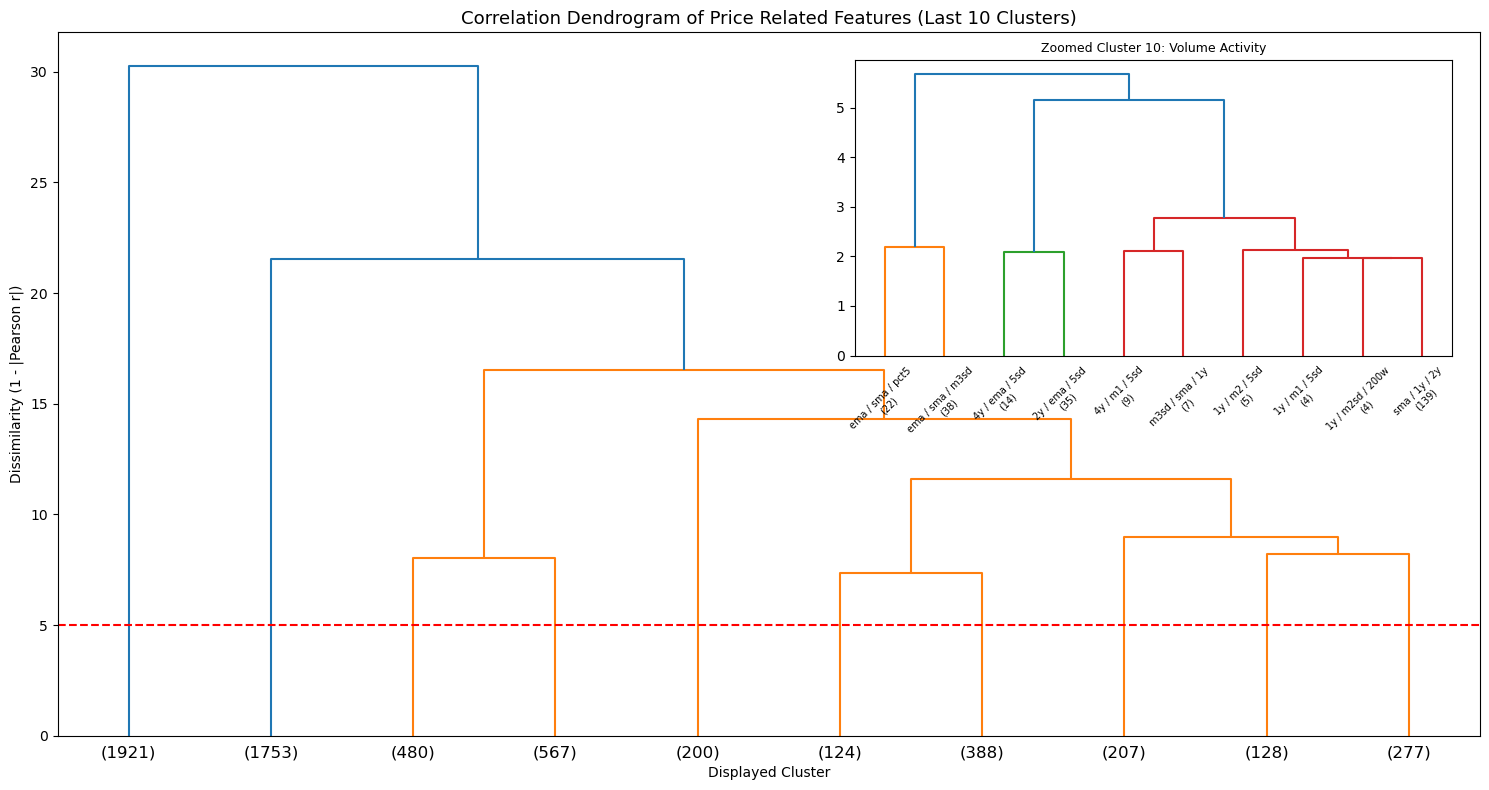

In [32]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(figsize=(15, 8))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=10,
    show_leaf_counts=True,
    ax=ax
)

ax.set_title(
    "Correlation Dendrogram of Price Related Features (Last 10 Clusters)",
    fontsize=13
)
ax.set_xlabel("Displayed Cluster")
ax.set_ylabel("Dissimilarity (1 - |Pearson r|)")
ax.axhline(y=5, color="red", linestyle="--")


zoom_corr = prices[zoom_cols].corr(method="pearson").abs()
zoom_dist = 1 - zoom_corr
Z_zoom = linkage(squareform(zoom_dist, checks=False), method="ward")

inset_ddata = dendrogram(
    Z_zoom,
    truncate_mode="lastp",
    p=10,
    no_plot=True
)

inset_nodes = inset_ddata["leaves"]

inset_node_label_map = {}

for node in inset_nodes:
    members = get_cluster_members(node, Z_zoom, zoom_cols)
    label = make_topic_label(members)
    inset_node_label_map[node] = f"{label}\n({len(members)})"

def inset_label_func(node_id):
    return inset_node_label_map.get(node_id, str(node_id))


# CREATE THE INSET AXIS
axins = inset_axes(
    ax,
    width="42%",
    height="42%",
    loc="upper right",
    borderpad=2
)

dendrogram(
    Z_zoom,
    truncate_mode="lastp",
    p=10,
    leaf_label_func=inset_label_func,
    ax=axins,
    leaf_rotation=45,
    leaf_font_size=7
)

axins.set_title(
    f"Zoomed Cluster {selected_cluster_id}: {cluster_label_map[selected_cluster_id]}",
    fontsize=9
)
axins.set_xlabel("")
axins.set_ylabel("")

plt.tight_layout()
plt.show()

In [33]:
fig.savefig(FIGURES_DIR / "price_dendrogram_new.png", dpi=300)